<center><h1 style="margin-bottom: 0px;">Artificial Intelligence (25/26)</h1></center>
<center><h2 style="margin-top: 0px;">Adversarial Search Strategies and Decision Trees</h2></center>

#### <center> Joana Antunes (202405702), Sílvia Pinto (202405988) </center> <br>

In [7]:
import copy
import time
import random
import math
import os
import csv
from collections import Counter
from gameplay_functions import *

TypeError: 'NoneType' object is not iterable

### **1. Introduction** <br>
<div style="text-align: justify;"><p style="text-indent: 2em;">This report details the development and implementation of a program designed to master PopOut, a dynamic variant of the classic Connect-4 game. Unlike traditional gameplay, PopOut introduces a "pop" mechanic where players can remove their own discs from the bottom row, shifting the entire column downward and fundamentally altering the board state. 
<p style="text-indent: 2em;">The primary objective of this assignment is to explore and implement adversarial search for the Pop Out game, and learning algorithms to play it. To achieve this, we implemented Monte Carlo Tree Search (MCTS) and Decision Trees to power the decision-making process. MCTS was implemented using Upper Confidence Bound for Trees (UCT) as an evaluation function to balance exploration and exploitation during move selection. Decision Trees were implemented using the ID3 procedure and a custom dataset generated by our MCTS implementation, mapping specific game states to optimal moves. 
<p style="text-indent: 2em;">These search algorithms allowed us to develop three distinct gameplay modes: Human vs. Human, Human vs. Computer and Computer vs. Computer (pitting different algorithms against one another). Adhering to the project guidelines, all core logic for the decision trees was implemented from scratch without the use of automated libraries like scikit-learn. 
<p style="text-indent: 2em;">This report documents our game implementation, technical decisions, strategies used to optimize our search algorithms and an analysis of the results obtained across both search and classification tasks.

### **2. Pop Out - Game Rules** <br>
<div style="text-align: justify;"><p style="text-indent: 2em;">There are three types of moves in Pop Out:

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**1.** *Insert piece (I): Places a piece at the top of a column, which then falls until the lowest empty position in that column.*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**2.** *Remove piece (R): Removes the base piece of a column, causing every piece above it to fall one position.*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**3.** *Draw (D): Declares a tie - only if the board is completely full, or the current game state has been repreated three or more times.*

<p style="text-indent: 2em;">The goal of the game is to make a 4-in-row - either horizontally, vertically or diagonally.
<p style="text-indent: 2em;">IMPORTANT RULE: If a "remove" play causes a 4-in-row for both players, the winner is the player who made that "remove".</div>

### **3. Pop Out - Implementation** <br>
<div style="text-align: justify;"><p style="text-indent: 2em;">The core part of our implementation is the class Pop Out, which represents an instance of a Pop Out game. It has a board, which starts as an empty 7 by 6 grid, a current player (starts as "O" by default), a board history to register the number of times we have been in a certain state of the board, the winner of the game (starts as None, but will eventually become defined when the game ends) and the state of the game (is it finished or still running).</div>

In [ ]:
class Pop_Out():                                                    # The class which represents an instance of our Pop Out game.
    def __init__(self, board = None, cur_player = "O", board_history = None, winner = None, terminal = False):
        # An instance of the game has a board, the current player, the history of previous moves and the winner of the game (if it is finished).
        self.board = copy.deepcopy(board) if board else [["."] * 7 for _ in range(6)]
        self.cur_player = cur_player
        #We need the board history to know if we have already been in a certain state more than 3 times, in order to allow players to call a draw.
        self.board_history = copy.deepcopy(board_history) if board_history else {self.board_to_string(): 1}
        self.winner = winner
        self.terminal = terminal 

<div style="text-align: justify;"><p style="text-indent: 2em;">The following functions define a few simple actions that will be helpful for other operations on our game. Respectively, board_to_string converts a matrix board into a printable string which can be used in our text interface; change_player allows to change players between each play; board_is_full checks if the board has every single position filled; register_state adds the current state to the board_history.</div>

In [ ]:
def board_to_string(self):                                          # Turns the board into a string, in order to be printable and readable for text interface.
    s = ""
    for row in self.board: s += " ".join(row) + "\n"
    return s

Pop_Out.board_to_string = board_to_string

def change_player(self):                                            # Switches players
    self.cur_player = "X" if self.cur_player == "O" else "O"

Pop_Out.change_player = change_player
    
def board_is_full(self):                                            # Checks if the board is completely full (in which case the draw is playable)
    return all(cell != "." for cell in self.board[0])

Pop_Out.board_is_full = board_is_full

def register_state(self):                                           # Uploads the state in the board history.
    key = self.board_to_string()
    if key in self.board_history:                                   # If it has already been visited, add 1 to its number of visits.
        self.board_history[key] += 1
    else:
        self.board_history[key] = 1                                 # Else, mark it as visited once.

Pop_Out.register_state = register_state

<div style="text-align: justify;"><p style="text-indent: 2em;">Then, we have implemented the functions for "insert" and "remove" operations. Since a move made by a human player can be invalid for a certain state of the game, we have created the invalid_move function to handle those cases and guide the player; it is available in the file gameplay_functions.py, as well as the clear_terminal function.</div>

In [ ]:
def insert(self, col, printing):                                    # Performs an "insert" move.
    c = col - 1
    if self.board[0][c] != ".": invalid_move(self)                  # If the column is full already, declare the move invalid.
    self.board[0][c] = self.cur_player                              # Else, insert current player's piece at the top...
    row = 0
    while row < 5 and self.board[row + 1][c] == ".":                # and let it fall until it lands on another piece, or the end of the board.
        if (printing):                                              # Produces the animation of the fall, which will not be seen during searching phase of MCTS.
            clear_output(wait = True)
            print(self.board_to_string())
            time.sleep(0.5)
        self.board[row][c] = "."
        self.board[row + 1][c] = self.cur_player
        row += 1
    if (printing): clear_output(wait = True)
    self.update_terminal_status()                                   # Checks if this "insert" has produced a win...
    if not self.terminal:                                           # If not, change players and register this visit to the board.
        self.change_player()
        self.register_state()

Pop_Out.insert = insert

def remove(self, col, printing):                                    # Performs a "remove" move.
    c = col - 1
    if self.board[5][c] != self.cur_player: 
        invalid_move(self)                                          # If the bottom piece does not belong to the player, declare move as invalid.
        return
    for row in range(5, 0, -1):                                     # Else, remove piece and let the ones above it fall down 1 place.
        if (printing):                                              # Produces the animation of the fall, which will not be seen during searching phase of MCTS.
            clear_output(wait = True)
            print(self.board_to_string())
            time.sleep(0.5)
        self.board[row][c] = self.board[row - 1][c]
    self.board[0][c] = "."
    if (printing): clear_output(wait = True)
    self.update_terminal_status()                                   # Checks if this "remove" has produced a win...
    if not self.terminal:                                           # If not, change players and register this visit to the board.
        self.change_player()
        self.register_state()

Pop_Out.remove = remove

<div style="text-align: justify;"><p style="text-indent: 2em;">Next, we have the functions which check if a player has made a 4-in-row (function has_four) and which evaluate if the game has ended based on the current 4-in-rows in the board (update_terminal_status). The function check is responsible for finding 4-in-rows in each line, column and diagonal, and it is available in file gameplay_functions.py. Lastly, the function apply_move is responsible for executing a given move, depending on its kind - insert, remove, draw.</div>

In [ ]:
def has_four(self, player):                                         # Function that checks if a player has made a 4-in-row in the current game state.
    for row in range(6):                                            # Checks each row first,
        if check(self.board[row], player): return True

    for col in range(7):                                            # then each column,
        cur_col = []
        for row in range(6):
            cur_col.append(self.board[row][col])
        if check(cur_col, player): return True

    for row in range(3):                                            # then the diagonals.
        for col in range(4):
            diag = []
            diag2 = []
            for i in range(4):
                diag.append(self.board[row + i][col + i])
                diag2.append(self.board[row + 3 - i][col + i])
            if check(diag, player) or check(diag2, player): return True
    return False

Pop_Out.has_four = has_four

def update_terminal_status(self):                                   # Checks if the game has ended, in its current state.
    o_wins = self.has_four("O")
    x_wins = self.has_four("X")

    if not o_wins and not x_wins: return                            # If no one has won yet, things remain the same.
    self.terminal = True                                            # If someone has won. then the game has terminated.
    if o_wins and x_wins: self.winner = self.cur_player             # If both players win, we are in the presence of a "remove", so the current player wins.
    elif o_wins: self.winner = "O"                                  # Else, if only O wins, declare it the winner.
    elif x_wins: self.winner = "X"                                  # Lastly, if only X wins, declare it the winner.

Pop_Out.update_terminal_status = update_terminal_status

def apply_move(self, move, printing = True):                        # Reads a given move and executes the corresponding action. 
    kind, value = move[0], move[1]
    if kind == "I":                                                 # Perform "insert"
        self.insert(value, printing)                            
    elif kind == "R":                                               # Perform "remove"
        self.remove(value, printing)                            
    elif kind == "D":                                               # Perform "draw"...
        if self.board_is_full() or self.board_history.get(self.board_to_string(), 0) >= 3:
            self.winner = None
            self.terminal = True                                    # and end the game,
        else: invalid_move(self)                                    # unless the conditions for a draw have not been met.

Pop_Out.apply_move = apply_move

<div style="text-align: justify;"><p style="text-indent: 2em;">Finally, we decided to create a separate class CVP_Pop_Out, which extends Pop_Out, to allow for a switch between player types (human and computer). This is made by overwriting the two functions which handle player status. The initialization function uses the exact same structure as Pop_Out, but adds a new variable "type_player" which indicates whether the current player is "human" or "computer". The starting player is randomized by the function "randomize_player", present in the gameplay_functions.py file. Then, when there is a change in players between moves, the function change_player also shifts the player type from "human" to "computer" and vice-versa.</div>

In [ ]:
class CVP_Pop_Out(Pop_Out):                                         # Extends Pop Out game by changing a couple of its functions...
    def __init__(self, board = None, cur_player = "O", board_history = None, winner = None, terminal = False, start_player = None):
        super().__init__(board, cur_player, board_history, winner, terminal)
        self.type_player = randomize_player(start_player)           # to allow for a human to play against a computer,

    def change_player(self):                                        # and to change the player type according to that.
        super().change_player()
        self.type_player = "human" if self.type_player == "computer" else "computer"

### **4. Monte Carlo Tree Search** <br>
<div style="text-align: justify;"><p style="text-indent: 2em;">We proceeded to create various versions of Monte Carlo Tree Search (MCTS) algorithm. It is based on the execution of multiple random simulations (playouts) starting from a given state of the game. For each possible move:</div>

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**1.** *That move is applied to the current game state;*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**2.** *From that point on, the game is simulated in a random way;*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**3.** *The final result of that random simulation is registered (victory, defeat or draw);*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**4.** *The process described in points 2 and 3 is repeated multiple times, and the mean of the results is calculated.*

<div style="text-align: justify;"><p style="text-indent: 2em;">The chosen move is the one with the best mean result.</div><br>

<div style="text-align: justify;"><p style="text-indent: 2em;">Before implementing MCTS, we needed to add a few more functions to our Pop_Out class. These will be used in our Monte Carlo algorithm and, respectively, they allow us to clone a game by creating a new one with the exact same characteristics (function clone), return the valid moves for a current game state (function get_valid_moves) and, finally, return the result of our game in the form of a "reward" for a simulation of MCTS (function get_result). </div>

In [ ]:
def clone(self):                                                    # Function that clones a Pop Out game, to be used for Monte Carlo Tree Search.
    return Pop_Out(board = self.board,                              # Simply creates a new game with all of the exact characteristics of the previous one.
                cur_player = self.cur_player, 
                board_history = self.board_history, 
                winner = self.winner, 
                terminal = self.terminal)  

Pop_Out.clone = clone

def get_valid_moves(self):                                          # For the computer to select its best move, shows it what moves are available.
    moves = []
    for col in range(7):                                        
        if self.board[0][col] == ".":                               # In each column, checks if there is space for an insert at the top.
            moves.append(("I", col + 1))
        if self.board[5][col] == self.cur_player:                   # Also, checks if the last cell belongs to the current player; if so, it is removable.
            moves.append(("R", col + 1))

    if self.board_is_full() or self.board_history.get(self.board_to_string(), 0) >= 3: 
        moves.append(("D", None))                                   # If the board is full, or the current state has been repeated 3 or more times, then draw is available.
    return moves

Pop_Out.get_valid_moves = get_valid_moves

def get_result(self, player):                                       # Returns the result of the game as a "reward" value for MCTS to evaluate the path.
    if self.winner is None: return 0.5
    if self.winner == player: return 1.0
    return 0.0

Pop_Out.get_result = get_result

#### **4.1. Standard Monte Carlo with UCT** <br>
<div style="text-align: justify;"><p style="text-indent: 2em;">Now, we implement the standard Monte Carlo Tree Search algorithm with UCT(Upper Confidence bound for Trees). MCTS builds a search tree incrementally and focuses its simulations on the most promising moves. The UCT formula used to select the best child balances exploitation (choosing moves that have performed well) and exploration (trying moves that have been visited less):

$$UCT = \frac{w}{n} + c \cdot \sqrt{\frac{\ln N}{n}}$$

Where $w$ is the number of wins, $n$ is the number of visits to this node, $N$ is the total visits to the parent, and $c$ is the exploration constant (typically $\sqrt{2} \approx 1.41$).
<p style="text-indent: 2em;">The core stucture of this version is MCTSNode class, which represents a node in the search tree. Each node corresponds to the current game state, the move that led to it, a list of child nodes and two key statistics used by the UCT formula: the number of visits and the accumulated score. The best_child method implements the UCT formula, which balances between choosing moves that have performed well and trying moves that have been visited less. The roll_out function simulates the rest of the game from a given node.</div>

In [ ]:
class MCTSNode:
    def __init__(self, state, parent=None, move=None):
        self.state = state                                          # Current game state.
        self.parent = parent                                        # Parent node in the tree.
        self.move = move                                            # Move that led to this state.
        self.children = []                                          # List of child nodes.
        self.untried_moves = state.get_valid_moves()                # Moves not yet explored.
        self.visits = 0                                             # Number of times node was visited.
        self.score = 0.0                                            # Total reward accumulated.
        self.move_player = "X" if state.cur_player == "O" else "O"  # Player who made the move that led to this node.

    def fully_expanded(self):                                       # Check if all possible moves from this node have been explored.
        return len(self.untried_moves) == 0
    
    def best_child(self, exp = 1.41):                               # Select the best child using UCT.
        best_score = -float("inf")
        best_child = None

        for child in self.children:
            exploitation = child.score / child.visits               # "How good has this node been so far?"
            exploration = exp * math.sqrt(                          # Encourages trying less-visited nodes.
                math.log(self.visits)/child.visits)

            uct_score = exploitation + exploration                  # UCT formula balances exploration vs exploitation.
            if uct_score > best_score:
                best_score = uct_score
                best_child = child
        return best_child

    def expand(self):                                               # Expand the tree by applying one untried move.
        move = self.untried_moves.pop()                             # Take one unexplored move.
        new_state = self.state.clone()                              # Clone current state and apply the move.
        new_state.apply_move(move, printing=False)

        child = MCTSNode(new_state, parent=self, move=move)         # Create new child node.
        self.children.append(child)
        return child

    def update(self, result):                                       # Update node statistics after a simulation.
        self.visits += 1                                            # Increment visit count.
        self.score += result                                        # Add simulation result (win/loss/draw score).

#### **4.2. Monte Carlo with move memory** <br>
<div style="text-align: justify;"><p style="text-indent: 2em;">Building on the standard version of MCTS implementation, we developed a second tree search version that addresses a specific problem in Pop Out: because of the pop move, the same board state can be reached multiple times during a game, which can cause the algorithm to waste simulations exploring cycles. 
<p style="text-indent: 2em;">In order to solve this, this next version makes each node remember all the states that already have appeared on the path from the root to that node. When expanding, it only considers moves that lead to states not yet seen on that path. During the simulation phase (rollout), the same principle is applied — repeated states are avoided whenever possible, and only used as a fallback if no other moves are available.
<p style="text-indent: 2em;">This avoids getting stuck in loops and produces more varied and realistic simulations. The trade-off is a small increase in computation per node, since visited states must be tracked and checked every time.</div>

In [ ]:
def state_key(state):
    return state.board_to_string() + "TURN:" + state.cur_player     # A state should include both the board and the current player.

class MemoryNode(MCTSNode):
    def __init__(self, state, parent=None, move=None, visited_states=None):
        super().__init__(state, parent, move)
        if visited_states is None:
            self.visited_states = {state_key(state)}                # Store all states already visited in this path.
        else:
            self.visited_states = set(visited_states)
            self.visited_states.add(state_key(state))
        self.untried_moves = self.non_repeating_moves()             # Only keep moves that do not create a repeated state.

    def non_repeating_moves(self):
        non_repeating_moves = []
        for move in self.state.get_valid_moves():
            new_state = self.state.clone()
            new_state.apply_move(move, printing=False)
            if state_key(new_state) not in self.visited_states: non_repeating_moves.append(move)
        return non_repeating_moves
    
    def expand(self):
        move = self.untried_moves.pop()                             # Expand the tree by applying one untried move.
        state2 = self.state.clone()                                 # Take one unexplored move.
        state2.apply_move(move, printing=False)                     # Clone current state and apply the move.
        child = MemoryNode(state2, self, move, self.visited_states) # Create new child node.
        self.children.append(child)
        return child

#### **4.3. Monte Carlo with heuristics** <br>
<div style="text-align: justify;"><p style="text-indent: 2em;">The third version of MCTS keeps the same tree structure as the standard one but replaces the random rollout with a heuristic-guided simulation, similar to what we have done in the second version of flat monte carlo. To chose the next move, it uses a simple heuristic: 

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**1. Win Immediately** *If there is a move that wins the game right away, take it;*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**2. Block the opponent** *Avoid moves that allow the opponent to win on the next turn;*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**3. Otherwise...** *If no such situations are detected, play randomly.*

<p style="text-indent: 2em;">The motivation behind this version is that random rollouts can be very misleading — a position that is clearly winning can look bad if the simulation plays randomly from it. By using smarter rollouts, the algorithm produces more realistic simulations and therefore better estimates of each move's value. The trade-off is that each simulation takes slightly longer, since the heuristic requires checking all valid moves at each step.</div>

In [ ]:
def heuristic_move(state):                                          # Selects options that produce immediate win, and avoids immediate losses.
    safe_moves = []                                                 # List to store moves that do not immediately lose the game
    for move in state.get_valid_moves():                            # Iterate through all possible valid moves.
        clone = state.clone()
        clone.apply_move(move, printing=False)
        if clone.winner == state.cur_player: return move            # If this move wins immediately, play it.
        elif clone.terminal: safe_moves.append(move)
        else:
            opponent_wins = False                                   # Check whether the opponent can win immediately after this move.
            for opp_move in clone.get_valid_moves():
                temp = clone.clone()
                temp.apply_move(opp_move, printing=False)
                if temp.winner == clone.cur_player:                 # If the opponent can win, mark it as unsafe.
                    opponent_wins = True
                    break
                if not opponent_wins: safe_moves.append(move)       # If the opponent cannot win immediately, consider this move safe.
    # If there are safe moves available, choose one randomly. If no safe moves exist, fall back to a completely random move.
    return random.choice(safe_moves) if safe_moves else random.choice(state.get_valid_moves())

In [ ]:
def rollout(state, mode):                                           # Perform a simulation (playout) from a given state.
    simulation = state.clone()
    while not simulation.terminal:                                  # Play random / with heuristic until the game ends.
        if mode == "random": move = random.choice(simulation.get_valid_moves())
        elif mode == "heuristic": move = heuristic_move(simulation)
        simulation.apply_move(move, printing=False)
    return simulation

def memory_rollout(state):
    simulation = state.clone()
    visited_states = {state_key(simulation)}

    while not simulation.terminal:
        non_repeating_moves = []
        for move in simulation.get_valid_moves():
            temp = simulation.clone()
            temp.apply_move(move, printing=False)

            if state_key(temp) not in visited_states:
                non_repeating_moves.append(move)
              
        if non_repeating_moves:                                      # Prefer non-repeating moves.
            move = random.choice(non_repeating_moves)
        else: move = random.choice(simulation.get_valid_moves())     # Fallback: if all moves repeat, choose any valid move

        simulation.apply_move(move, printing=False)
        visited_states.add(state_key(simulation))

    return simulation

def mcts_move(state, iterations, mode):                             # Main MCTS function: returns the best move from the current state.
    root = MCTSNode(state.clone())

    for _ in range(iterations):
        node = root
        while not node.state.terminal and node.fully_expanded():    # SELECTION: Traverse the tree by selecting best children until we reach a leaf.
            if mode == "memory" and not node.children: break
            node = node.best_child()

        if not node.state.terminal and node.untried_moves:          # EXPANSION: If we haven't reached a terminal state, expand one new child.
            node = node.expand()

        if mode == "standard":
            final_state = rollout(node.state, "random")             # SIMULATION: Play randomly from this node until the game ends.
        elif mode == "heuristic":
            final_state = rollout(node.state, "heuristic")
        else: final_state = memory_rollout(node.state)

        while node is not None:                                     # BACKPROPAGAITON: Propagate the result back up the tree.
            result = final_state.get_result(node.move_player)       # Get result from perspective of the player who just moved.
            node.update(result)
            node = node.parent                                      # Move up the tree.

    if mode == "memory" and not root.children:                      # In second version: If no child was created, fallback to a legal move.
        return random.choice(state.get_valid_moves())

    best_child = max(root.children, key=lambda child: child.visits) # Choose the most visited child as the final move.
    return best_child.move

#### **4.4. Comparisons between Monte Carlo versions**


### **5.Dataset Generation**

The dataset is generated by allowing a Monte Carlo-based agent to play games automatically. At each turn, we store the current game state and the move selected by the algorithm. Each row therefore represents a supervised learning example: the input is the board state and the target label is the move chosen by the search algorithm.

This dataset can later be used to train decision tree models that try to imitate the decisions made by the Monte Carlo agent.

In [ ]:
def generate_dataset(game, num_games=100, filename="game_data.csv"):
    dataset = []
    for i in range(num_games):
        clone = game.clone()
        while not clone.terminal:
            best_move = mcts_move(clone, simulations_per_move=100)
            dataset.append(game.features + [best_move])
            clone.apply_move(best_move)
            
    # Save to CSV for the ID3 process
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(game.feature_names + ["move"])
        writer.writerows(dataset)

### **6.Decision trees**

Decision trees are one of the simplest models and most interpretable machine learning algorithms. The type of decision trees we are going to implement is ID3(Iterative Dichotomiser 3), which builds the tree recursively by always choosing the attribute that provides the most information about the correct classification of the object. We start by implementing some functions we are going to need.


The first step to implement this model is to implement the entropy function, which represents the level of uncertainty over a certain variable.
The entropy of a certain label is obtain by the formula:
$$H(X) = \sum_{i=1}^{n} -P(x_i) \log_2 P(x_i)$$
In this formula $P(x_i)$ is the proportion of examples belonging to class $x_i$. When all example belong to the same class the entropy is 0 and when the example are equally split between the classes the entropy is 1.

In [ ]:
def entropy(labels):
    """
    Calculates the entropy of a list of labels.
    labels: list of class values (e.g. ['setosa', 'setosa', 'virginica'])
    """
    n = len(labels)
    if n == 0:
        return 0.0
    
    counts = Counter(labels)  # counts how many times each class appears
    result = 0.0

    for count in counts.values():
        p = count / n           # probability of this class
        result += -p * math.log2(p)
    return result

Now we implement the information gain function. The information gain of an attribute is defined as the reduction in entropy that is achieved by splitting the examples according to that attribute:

$$H(X) = \sum_{i=1}^{n} -P(x_i) \log_2 P(x_i)$$


In [ ]:
def information_gain(data, labels, attribute):
    """
    Calculates the information gain of splitting data by a given attribute.
    data: list of dictionaries (each dictionary is one example)
    labels: list of class labels corresponding to each example
    attribute: the attribute we are testing
    """
    n = len(labels)
    parent_entropy = entropy(labels)  # H(C)=entropy before the split
    
    # Group examples by the value of the attribute
    groups = {}
    for i, row in enumerate(data):
        val = row[attribute]
        if val not in groups:
            groups[val] = []
        groups[val].append(labels[i])
    
    # H(C|A) — weighted average entropy after the split
    weighted_entropy = 0.0
    for group_labels in groups.values():
        weight = len(group_labels) / n
        weighted_entropy += weight * entropy(group_labels)
    
    return parent_entropy - weighted_entropy


Next we implemthe the ID3 algorithm itself. The ID3 aproach always chooses the attribute with the highest information gain as the next splitting node. This process is applied recursively until one of the next base cases occurs:

- all examples have the same class;

- there are no more attributes to split on;

- there are no more examples left in a branch;

- it reached a maxium depht.

The tree implemented is built using two components:

- DecisionNode class, that represents a node in the decision tree. A node can only be an internal node, which means it has an attribute to split on and a set of children, or a leaf node, which means it has a class label and represents a final classification.

- ID3 function, that builds the tree recursively. At each iteration this function selects the attribute with the highest information gain and creates a branch for each of its possible values. The algorithym is apllied again to each subset of examples and the recursion only stops when the bases cases refered previously are reached.

In addition, the max_depth parameter is important for the Popout dataset, because its complexity is extremely hight and that could lead to the tree learning general patterns instead of making predictions.

In [ ]:
from collections import Counter
import math

class DecisionNode:
    """
    Represents a node in the decision tree.
    - If it's a leaf node, it has a label (the class to predict)
    - If it's an internal node, it has an attribute to split on and children
    """
    def __init__(self, attribute=None, label=None):
        self.attribute = attribute  # attribute to split on (internal node)
        self.label = label          # class label (leaf node)
        self.children = {}          # value = child node

    def is_leaf(self):
        return self.label is not None


def id3(data, labels, attributes, max_depth=None, depth=0):
    """
    Builds a decision tree recursively using the ID3 algorithm.
    data: list of dictionaries (each dictionary is one example)
    labels: list of class labels
    attributes: set of attributes still available to split on
    max_depth: maximum depth of the tree (None = no limit)
    depth: current depth (used internally)
    """
    # Base case 1: all examples have the same class
    if len(set(labels)) == 1:
        return DecisionNode(label=labels[0])

    # Base case 2: no attributes left or max depth reached
    if not attributes or (max_depth is not None and depth >= max_depth):
        most_common = Counter(labels).most_common(1)[0][0]
        return DecisionNode(label=most_common)

    # Choose the attribute with the highest information gain
    best_attr = max(attributes, key=lambda a: information_gain(data, labels, a))

    node = DecisionNode(attribute=best_attr)
    remaining_attrs = attributes - {best_attr}

    # Get all possible values of the best attribute
    values = set(row[best_attr] for row in data)

    for val in values:
        # Split examples by this value
        subset_data   = [data[i]   for i in range(len(data)) if data[i][best_attr] == val]
        subset_labels = [labels[i] for i in range(len(data)) if data[i][best_attr] == val]

        if not subset_data:
            # Base case 3: no examples for this branch
            # use most common label of the parent
            most_common = Counter(labels).most_common(1)[0][0]
            node.children[val] = DecisionNode(label=most_common)
        else:
            # Recurse
            node.children[val] = id3(subset_data, subset_labels, remaining_attrs, max_depth, depth + 1)

    return node

After building the tree, we also need a function to classify new unseen examples. The classify function is responsable for that, it traverses the tree from the root, at each iternal node reads the value of the corresponding attribute from the sample and following the matching branch, until it reachesa leaf node whose label is returned as the prediction .

In [14]:
def classify(node, sample, default_label=None):
    """
    Classifies a sample by traversing the decision tree.
    If a value was not seen during training, returns default_label.
    """
    if node.is_leaf():
        return node.label
    val = sample.get(node.attribute)
    if val not in node.children:
        return default_label
    return classify(node.children[val], sample, default_label)

### **6.1. Implement ID3 algorithym to iris dataset**


Like it was asked in the guidelines of the project, we are now implementing ID3 algorithym to the dataset iris as a warm-up. 
This dataset is composed by 150 samples of plants from three differents classes: Iris setosa, Iris virginica and Iris versicolor. The attributes of each class are sepal length, sepal width, petal length and petal width.

As we can see this attributes are numerical values and ID3 requires categorical values so we need to discretise each attribute. We choose to do that using 3 intervals, in order to ensure that each interval contains a similar number of examples, which helps building trees with better performances:

- **low** - values bellow 33rd percentile;

- **medium** - values between the 33rd and the 67th percentile;

- **hight** - values above the 67th percentile.

After discretisation, we divide the dataset in to training set(80%) and a test set(20%). For that, we use a fixed random seed, this garantees that the train and test split is always identical every time we run it, making our results reproducible.
We then train the algorithym and calculate is accuary and produce its confusion matrix.



Train: 120 samples | Test: 30 samples
Accuracy on test set: 93.33%


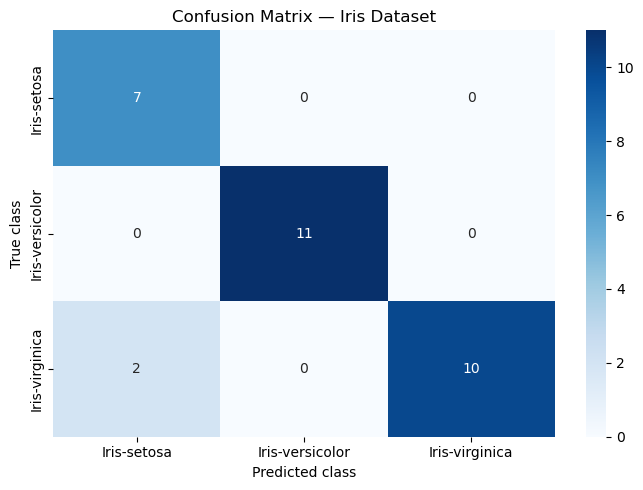

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("iris.csv")
numeric_cols = ['sepallength', 'sepalwidth', 'petallength', 'petalwidth']

# Discretise numerical values into low/medium/high using quantiles
df_disc = df.copy()
thresholds = {}

for col in numeric_cols:
    q33 = df[col].quantile(0.33)
    q67 = df[col].quantile(0.67)
    thresholds[col] = (q33, q67)
    def discretize(val, low=q33, high=q67):
        if val <= low: return 'low'
        if val <= high: return 'medium'
        return 'high'
    df_disc[col] = df[col].apply(discretize)

# Train/test split (80/20)
np.random.seed(42)
idx = np.random.permutation(len(df_disc))
split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

train_data   = df_disc.iloc[train_idx][numeric_cols].to_dict(orient='records')
train_labels = df_disc.iloc[train_idx]['class'].tolist()
test_data    = df_disc.iloc[test_idx][numeric_cols].to_dict(orient='records')
test_labels  = df_disc.iloc[test_idx]['class'].tolist()

print(f"Train: {len(train_data)} samples | Test: {len(test_data)} samples")

# Train the tree
tree_iris = id3(train_data, train_labels, set(numeric_cols), max_depth=6)

# Evaluate
default = Counter(train_labels).most_common(1)[0][0]
predictions = [classify(tree_iris, s, default) for s in test_data]
accuracy = sum(p == t for p, t in zip(predictions, test_labels)) / len(test_labels)
print(f"Accuracy on test set: {accuracy:.2%}")

# Compute confusion matrix
classes = sorted(set(test_labels))
n = len(classes)
matrix = np.zeros((n, n), dtype=int)
class_to_idx = {c: i for i, c in enumerate(classes)}

for true, pred in zip(test_labels, predictions):
    matrix[class_to_idx[true]][class_to_idx[pred]] += 1

# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion Matrix — Iris Dataset')
plt.tight_layout()
plt.show()


Our implementation of the ID3 has an accuracy of 93.33%, which shows that its working correctly. Observing the confusion matrix we can see:

- **Iris setosa** — all 7 examples were correctly classified. This is expected since setosa is linearly separable from the other two classes and is very easy to distinguish;

- **Iris versicolor** — all 11 examples were correctly classified, showing the tree learned a reliable rule to identify this class;

- **Iris virginica** — 10 out of 12 examples were correctly classified. The 2 misclassified examples were predicted as Iris setosa, which is surprising since these two classes are usually well separated. This is likely a consequence of 
the discretisation — by grouping continuous values into only three intervals, some fine-grained distinctions between classes are lost, which can occasionally lead 
to misclassifications.



The assigment also requires us to represent the tree visually, therefore, we implement the fuctions get_tree_depth and get_tree_width, that recursively calculate the dimensions 
of the tree, which are used to automatically adjust the size of the figure we want. We also implement the function draw_tree that is responsable to making the drawing of the tree. At last, we have the function visualize_tree that calls draw_tree and allows us to view the tree created using the library matplotlib.

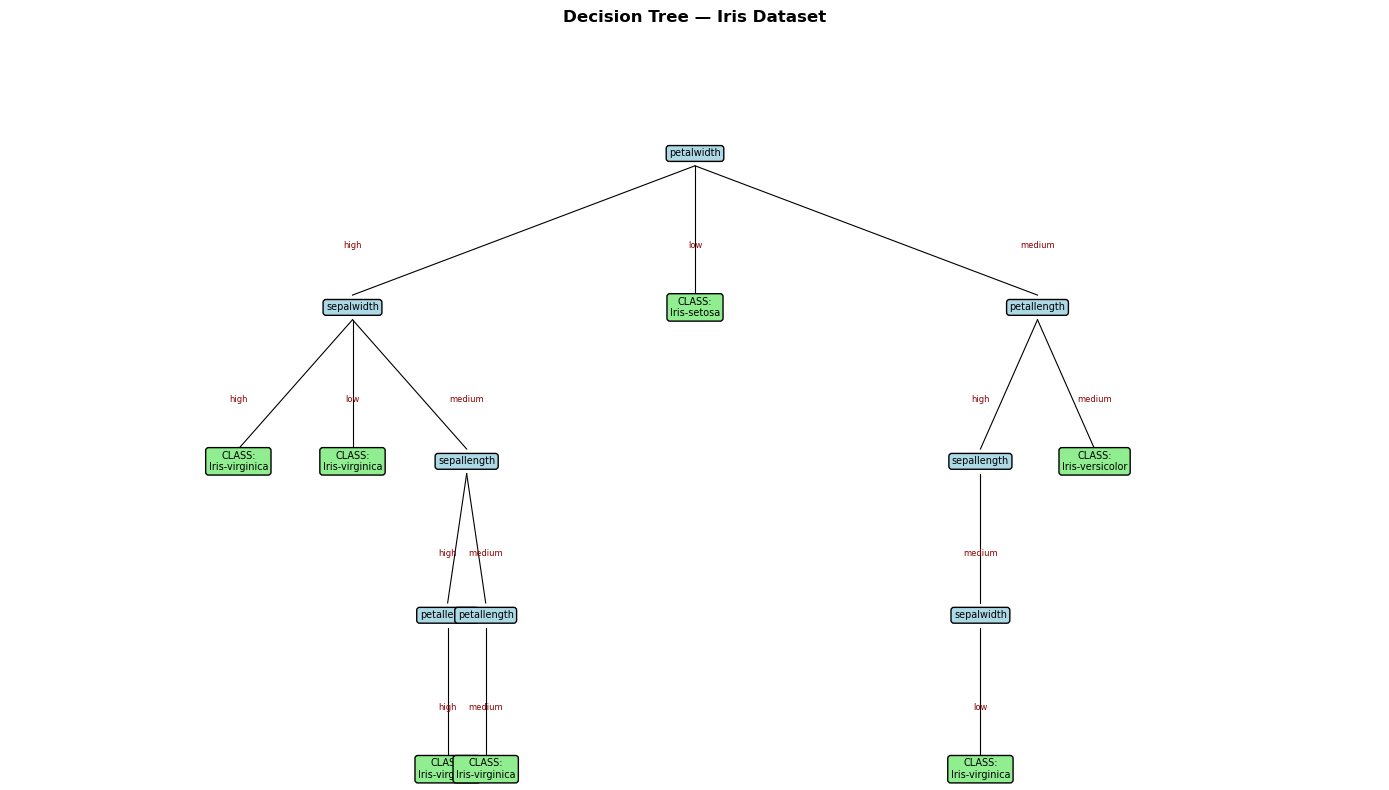

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def get_tree_depth(node):
    if node.is_leaf():
        return 0
    return 1 + max(get_tree_depth(child) for child in node.children.values())

def get_tree_width(node):
    if node.is_leaf():
        return 1
    return sum(get_tree_width(child) for child in node.children.values())

def draw_tree(node, ax, x, y, x_offset, y_offset, branch_label=""):
    # Draw the node box
    if node.is_leaf():
        color = "lightgreen"
        text = f"CLASS:\n{node.label}"
    else:
        color = "lightblue"
        text = f"{node.attribute}"

    bbox = dict(boxstyle="round,pad=0.3", facecolor=color, edgecolor="black")
    ax.text(x, y, text, ha="center", va="center", fontsize=7,
            bbox=bbox, wrap=True)

    # Draw branch label
    if branch_label:
        ax.text(x, y + y_offset * 0.4, str(branch_label),
                ha="center", va="center", fontsize=6, color="darkred")

    if not node.is_leaf():
        children = sorted(node.children.items(), key=lambda x: str(x[0]))
        n = len(children)
        total_width = x_offset * (n - 1)
        start_x = x - total_width / 2

        for i, (val, child) in enumerate(children):
            child_x = start_x + i * x_offset
            child_y = y - y_offset

            # Draw line to child
            ax.plot([x, child_x], [y - 0.02, child_y + 0.02],
                    color="black", linewidth=0.8)

            draw_tree(child, ax, child_x, child_y,
                      x_offset / max(n, 1.5), y_offset, val)


def visualize_tree(tree, title="Decision Tree"):
    depth = get_tree_depth(tree)
    width = get_tree_width(tree)

    fig_width = max(12, width * 2)
    fig_height = max(6, depth * 2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 0.2)
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold")

    draw_tree(tree, ax, x=0, y=0, x_offset=0.5, y_offset=0.25)
    plt.tight_layout()
    plt.show()


visualize_tree(tree_iris, title="Decision Tree — Iris Dataset")

### **6.2. Implement ID3 algorithym to PopOut game dataset**

In [ ]:
if (os.name == "nt"):
    os.system('start cmd /k python MAIN.py')
else: os.system("osascript -e 'tell application \"Terminal\" to do script \"python3 " + os.getcwd() + "/MAIN.py\"'")

### **7.Conclusions:**